In [14]:
#Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon, Patch
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import seaborn as sns
#Remove warnings
import warnings
warnings.filterwarnings("ignore")


In [15]:
#Importing data
df = pd.read_csv(r"C:\Users\nates\Downloads\valentines_day_spending_dataset.csv")
df.head()

,user_id,age,gender,city,relationship_status,celebrates_valentine,gift_type,spending_usd,mood,plans,previous_year_spending,sentiment_score
0,1,21,Female,Karachi,Single,No,NaN,118.99,Happy,Family,9.62,-0.59
1,2,45,Female,Rawalpindi,Single,No,NaN,31.41,Excited,Alone,128.50,0.36
2,3,23,Female,Lahore,Taken,No,Chocolates,79.80,Sad,Friends,53.06,-0.74
3,4,27,Male,Islamabad,Single,No,NaN,120.61,Sad,Family,93.27,-0.61
4,5,30,Male,Rawalpindi,Taken,Yes,Flowers,49.88,Excited,Family,137.06,-0.96


In [16]:
#Rename columns
df.rename(columns={'spending_usd': 'This Year', 'previous_year_spending':'Last Year'}, inplace=True)
#Calculate spending change from previous year
df['spending_change'] = df['This Year'] - df['Last Year']
print(df['spending_change'].describe())

count    200.000000
mean       2.696350
std       58.191298
min     -132.180000
25%      -33.125000
50%        2.320000
75%       40.160000
max      136.340000
Name: spending_change, dtype: float64


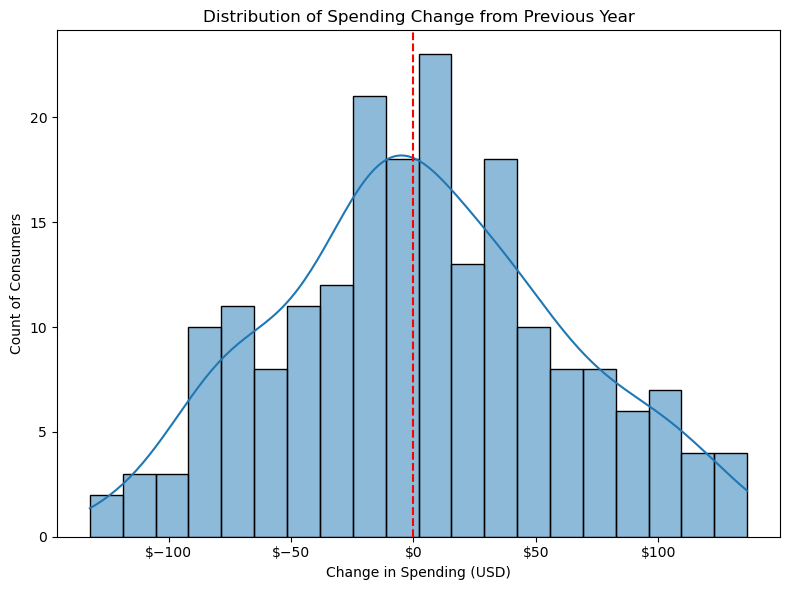

In [22]:
#Creating the histogram
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(df['spending_change'], bins=20, kde=True, ax=ax)
#Adding the zero line on this axes
ax.axvline(0, color='red', linestyle='--')

#Adding labels and title
ax.set_title("Distribution of Spending Change from Previous Year")
ax.set_xlabel("Change in Spending (USD)")
ax.set_ylabel("Count of Consumers")
#Add $ to x axis ticks
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

fig.tight_layout()
plt.show()

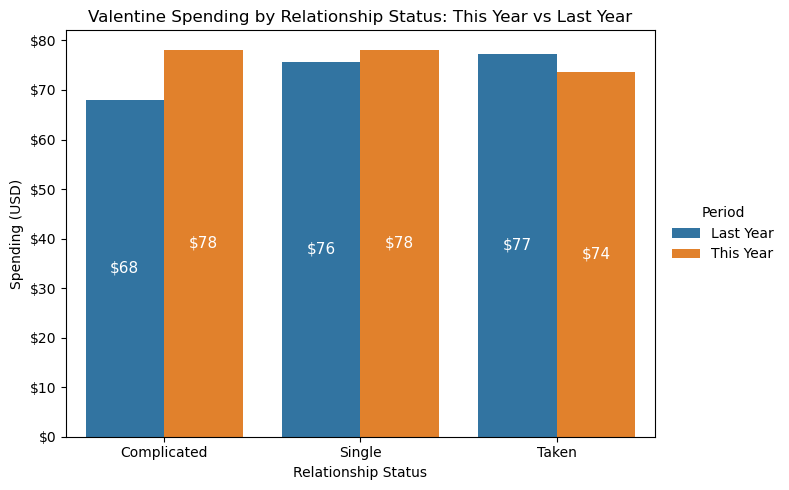

In [ ]:
#Creating the bar chart comparing this year vs last year spending by relationship status
fig, ax = plt.subplots(figsize=(8, 5))

#Making a long-form dataframe right inside the function
simple_df = df[["relationship_status", "This Year", "Last Year"]]

#Creating order based on "This Year spending"
order = (simple_df.groupby("relationship_status", as_index=False)["This Year"].mean().sort_values("This Year", ascending=False)["relationship_status"].tolist())

#Convert columns into a long format
long_df = simple_df.melt(id_vars="relationship_status", var_name="Period", value_name="Spending")

#Plot (no error bars, last year first) with the computed order
sns.barplot(data=long_df, x="relationship_status", y="Spending", hue="Period", hue_order=["Last Year", "This Year"], order=order, errorbar=None,  ax=ax)

#Adding labels and title
ax.set_title("Valentine Spending by Relationship Status: This Year vs Last Year")
ax.set_xlabel("Relationship Status")
ax.set_ylabel("Spending (USD)")

#Format y-axis with $
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Value labels on bars
for container in ax.containers:
    ax.bar_label(container, labels=[f'${v.get_height():,.0f}' for v in container],
        label_type='center', padding=0, fontsize=11, color='white')

#Legend outside (right side)
handles, labels = ax.get_legend_handles_labels()
ax.legend( handles, labels, title="Period", loc="center left", bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0, frameon=False)

fig.tight_layout()

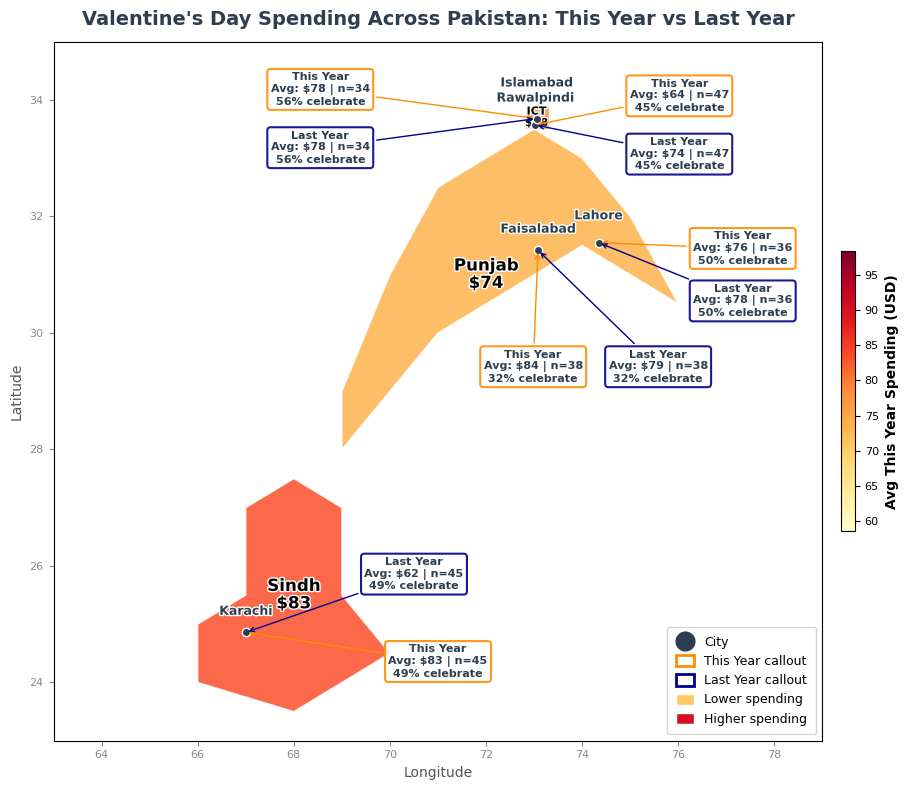

In [ ]:
#Creating a map visualization of spending by city
df_val = df.copy()

city_to_province = {"Karachi": "Sindh", "Faisalabad": "Punjab","Lahore": "Punjab", "Rawalpindi": "Punjab", "Islamabad": "ICT"}
df_val["province"] = df_val["city"].map(city_to_province)

province_polygons = {"Sindh": [(66,24),(68,23.5),(69,24),(70,24.5),(69,25.5),(69,27),(68,27.5),(67,27),(67,25.5),(66,25)],
    "Punjab": [(69,27),(69,28),(70,29),(71,30),(72,30.5),(73,31),(74,31.5),
    (75,31),(76,30.5),(75,32),(74,33),(73,33.5),(72,33),(71,32.5),(70,31),(69,29)],
    "ICT": [(72.8,33.5),(73.3,33.5),(73.3,33.9),(72.8,33.9)]}

province_centroids = {"Sindh": (68, 25.5), "Punjab": (72, 31), "ICT": (73.05, 33.7)}

city_coords = { "Karachi": (67.00, 24.86), "Lahore": (74.34, 31.55), "Rawalpindi": (73.02, 33.57), 
"Islamabad": (73.05, 33.68),"Faisalabad": (73.08, 31.42)}

period_colors = {"This Year": "#FF8C00", "Last Year": "#00008B"}

cmap_shared = cm.YlOrRd
prov_spending = df_val.groupby("province")["This Year"].mean()
norm_shared = Normalize(vmin=prov_spending.min() - 15, vmax=prov_spending.max() + 15)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")  # smaller
ax.set_facecolor("white")

for prov, coords in province_polygons.items():
    poly = Polygon(coords, closed=True)
    spending = prov_spending.get(prov, None)
    if spending is not None:
        poly.set_facecolor(cmap_shared(norm_shared(spending)))
        poly.set_alpha(0.85)
    poly.set_edgecolor("white")
    poly.set_linewidth(1)
    ax.add_patch(poly)

for prov, (cx, cy) in province_centroids.items():
    spending = prov_spending.get(prov, None)
    if spending is not None:
        label = f"{prov}\n${spending:.0f}"
        fs = 12 if prov != "ICT" else 8
        ax.text(cx, cy, label, ha="center", va="center",
                fontsize=fs, fontweight="bold", color="black",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

this_year_offsets = {
    "Karachi":( 4.0, -0.5), "Lahore":( 3.0, -0.1), "Rawalpindi":( 3.0,  0.5), 
    "Islamabad":(-4.5,  0.5), "Faisalabad":(-0.1, -2.0)}

last_year_offsets = {
    "Karachi":( 3.5,  1.0), "Lahore":( 3.0, -1.0), "Rawalpindi":( 3.0, -0.5), 
    "Islamabad":(-4.5, -0.5), "Faisalabad":( 2.5, -2.0)}
    
label_offsets = {"Karachi": 0.25, "Lahore": 0.35, "Rawalpindi": 0.35, "Islamabad": 0.50, "Faisalabad": 0.25,}

for city, (lon, lat) in city_coords.items():
    ax.plot(lon, lat, "o", color="#2c3e50", markersize=6,
            markeredgecolor="white", markeredgewidth=1, zorder=5)

    for period, off_dict, color in [
        ("This Year", this_year_offsets, period_colors["This Year"]),
        ("Last Year", last_year_offsets, period_colors["Last Year"]),
    ]:
        city_data = df_val[df_val["city"] == city]
        if len(city_data) == 0:
            continue
        avg = city_data[period].mean()
        n = len(city_data)
        celebrate_pct = (city_data["celebrates_valentine"] == "Yes").mean() * 100


        dx, dy = off_dict.get(city, (2.0, 0.3))
        annotation_text = f"{period}\nAvg: ${avg:.0f} | n={n}\n{celebrate_pct:.0f}% celebrate"
        ax.annotate(annotation_text, xy=(lon, lat), xytext=(lon + dx, lat + dy),
                    fontsize=8, fontweight="bold", color="#2c3e50", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor=color, alpha=0.9, linewidth=1.5),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1),
                    zorder=6)

    ax.text(lon, lat + label_offsets[city], city, ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#2c3e50",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
            zorder=7)

sm = cm.ScalarMappable(cmap=cmap_shared, norm=norm_shared)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02, aspect=20)
cbar.set_label("Avg This Year Spending (USD)", fontsize=10, fontweight="bold")
cbar.ax.tick_params(labelsize=8)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#2c3e50",
           markersize=16, markeredgecolor='white', markeredgewidth=1.5, label='City'),
    Patch(facecolor="white", edgecolor=period_colors["This Year"],
          linewidth=2, label="This Year callout"),
    Patch(facecolor="white", edgecolor=period_colors["Last Year"],
          linewidth=2, label="Last Year callout"),
    Patch(facecolor=cmap_shared(0.3), edgecolor="white", label="Lower spending"),
    Patch(facecolor=cmap_shared(0.8), edgecolor="white", label="Higher spending"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9,
          frameon=True, facecolor="white", edgecolor="#ccc",
          borderpad=0.7, handlelength=1.5, handleheight=1, labelspacing=0.5)

ax.set_title("Valentine's Day Spending Across Pakistan: This Year vs Last Year",
             fontsize=14, fontweight="bold", color="#2c3e50", pad=12)
ax.set_xlim(63, 79)
ax.set_ylim(23, 35)
ax.set_xlabel("Longitude", fontsize=10, color="#555")
ax.set_ylabel("Latitude",  fontsize=10, color="#555")
ax.tick_params(colors="#888", labelsize=8)

fig.tight_layout()
plt.show()

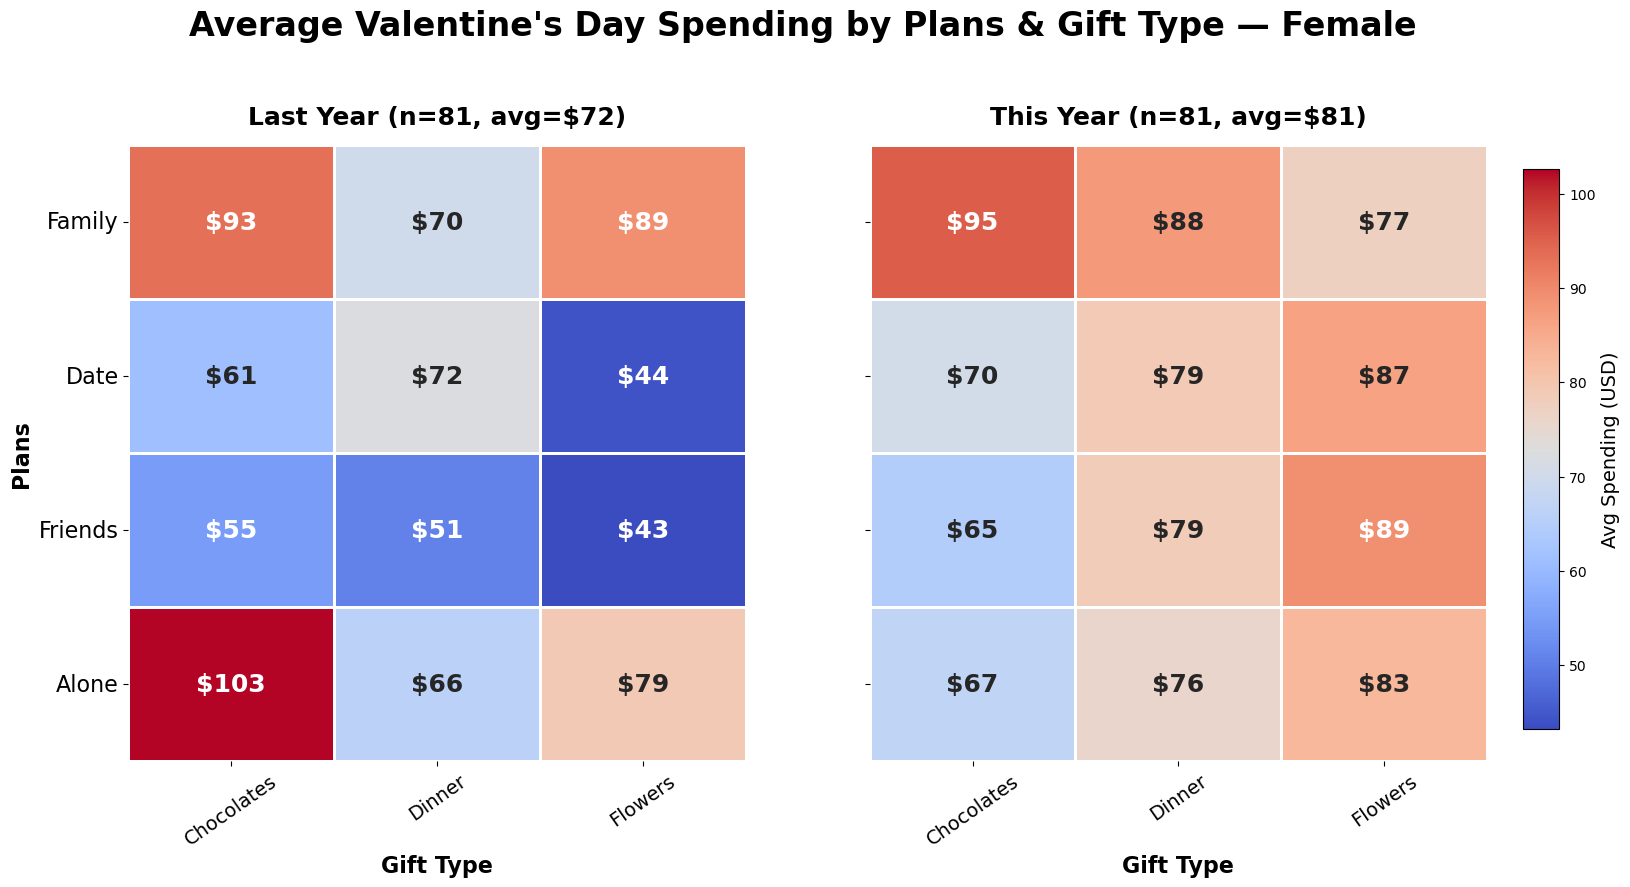

In [20]:
df_gifts = df.copy().dropna(subset=["gift_type"])

# Define parameters
gender = "Female"
periods = [("Last Year", "Last Year"), ("This Year", "This Year")]

# Prepare pivots
pivots = {}
all_rows = set()
all_cols = set()

subset = df_gifts[df_gifts["gender"] == gender]
for col, label in periods:
    piv = subset.pivot_table(index="plans", columns="gift_type", values=col, aggfunc="mean")
    pivots[label] = piv
    all_rows.update(piv.index)
    all_cols.update(piv.columns)

all_rows = sorted(all_rows)
all_cols = sorted(all_cols)

for label in pivots:
    pivots[label] = pivots[label].reindex(index=all_rows, columns=all_cols)

# Determine row order based on this year totals
row_order = pivots["This Year"].sum(axis=1).sort_values(ascending=False).index.tolist()

# Determine global min and max for consistent color scale
global_min = min(np.nanmin(piv.values) for piv in pivots.values())
global_max = max(np.nanmax(piv.values) for piv in pivots.values())

# Plotting
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=True, sharex=True)
fig.suptitle(f"Average Valentine's Day Spending by Plans & Gift Type — {gender}", fontsize=24, fontweight="bold", y=1.05)

for j, (col, label) in enumerate(periods):
    ax = axes[j]
    pivot = pivots[label].loc[row_order, all_cols]
    annot_labels = pivot.applymap(lambda v: f"${v:.0f}" if pd.notnull(v) else "")

    sns.heatmap(pivot, ax=ax, cmap="coolwarm", vmin=global_min, vmax=global_max, annot=annot_labels, fmt="",
        linewidths=2, linecolor="white", annot_kws={"fontsize": 18, "fontweight": "bold"}, cbar=False)

    n_users = len(subset)
    avg_spend = subset[col].mean()
    ax.set_title(f"{label} (n={n_users}, avg=${avg_spend:.0f})", fontsize=18, fontweight="bold", pad=15)

    if j == 0:
        ax.set_ylabel("Plans", fontsize=16, fontweight="bold")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', labelleft=False)

    ax.set_xlabel("Gift Type", fontsize=16, fontweight="bold")
    ax.tick_params(axis="x", labelsize=14, rotation=35)
    ax.tick_params(axis="y", labelsize=16, rotation=0)

# Dedicated colorbar axes — won't overlap either heatmap
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])

sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=global_min, vmax=global_max))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Avg Spending (USD)", fontsize=14)

plt.show()

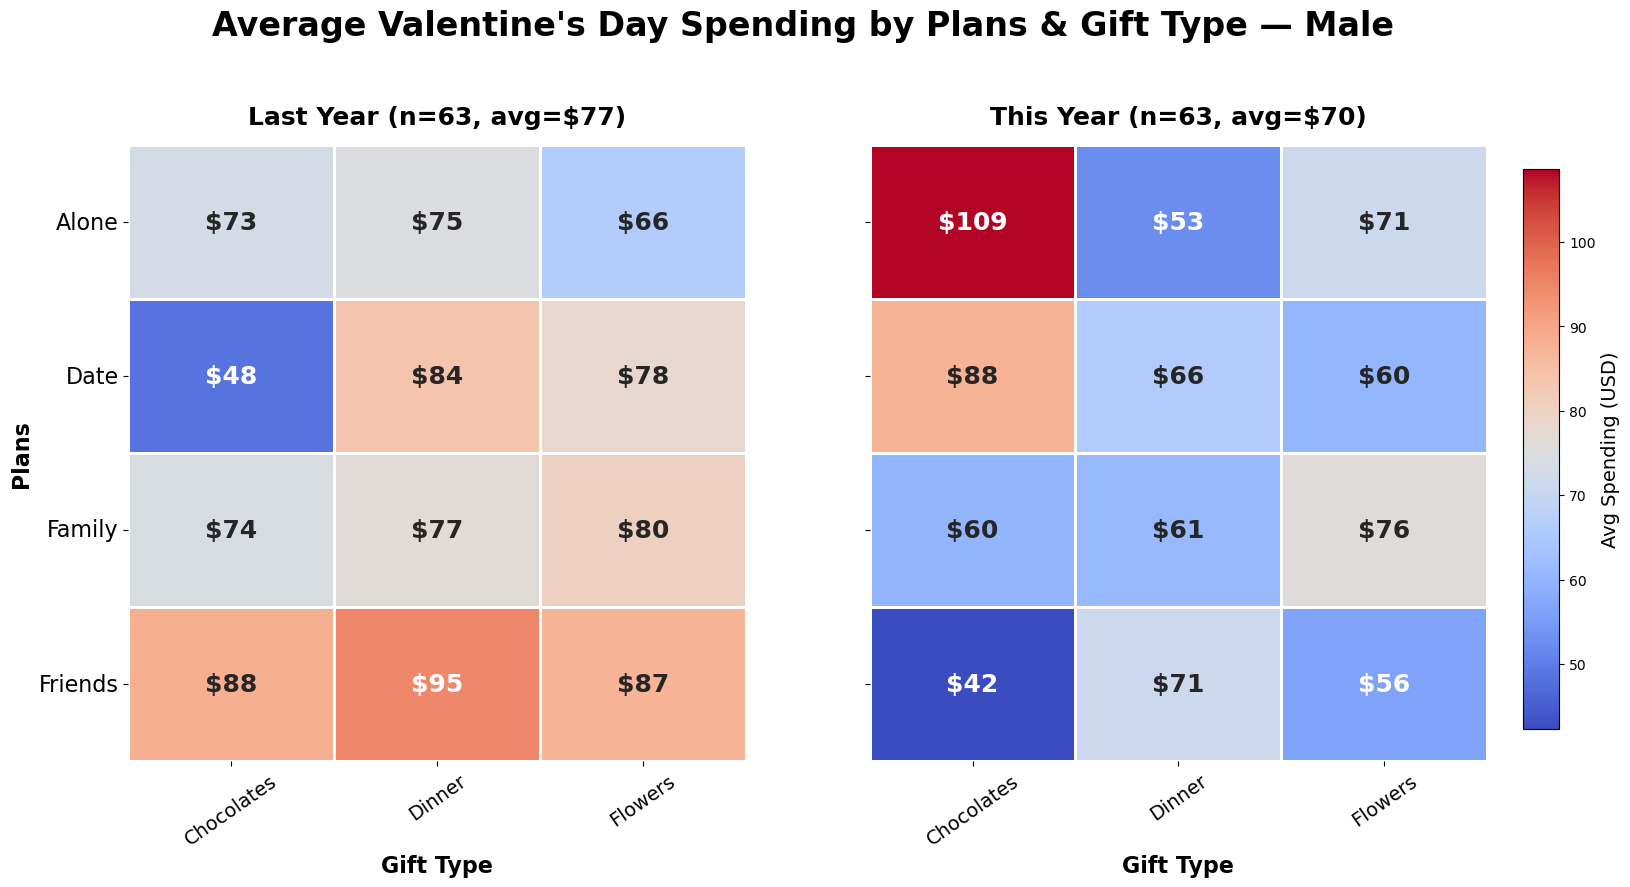

In [ ]:
#Defining parameters
gender = "Male"
periods = [("Last Year", "Last Year"), ("This Year", "This Year")]

#Creating pivots
pivots = {}
all_rows = set()
all_cols = set()

subset = df_gifts[df_gifts["gender"] == gender]
for col, label in periods:
    piv = subset.pivot_table(index="plans", columns="gift_type", values=col, aggfunc="mean")
    pivots[label] = piv
    all_rows.update(piv.index)
    all_cols.update(piv.columns)

all_rows = sorted(all_rows)
all_cols = sorted(all_cols)

for label in pivots:
    pivots[label] = pivots[label].reindex(index=all_rows, columns=all_cols)

#Determine row order based on this year totals
row_order = pivots["This Year"].sum(axis=1).sort_values(ascending=False).index.tolist()

#Determine global min and max for consistent color scale
global_min = min(np.nanmin(piv.values) for piv in pivots.values())
global_max = max(np.nanmax(piv.values) for piv in pivots.values())

#Plotting
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=True, sharex=True)
fig.suptitle(f"Average Valentine's Day Spending by Plans & Gift Type — {gender}", fontsize=24, fontweight="bold", y=1.05)

for j, (col, label) in enumerate(periods):
    ax = axes[j]
    pivot = pivots[label].loc[row_order, all_cols]
    annot_labels = pivot.applymap(lambda v: f"${v:.0f}" if pd.notnull(v) else "")

    sns.heatmap(pivot, ax=ax, cmap="coolwarm", vmin=global_min, vmax=global_max, annot=annot_labels, fmt="", 
    linewidths=2, linecolor="white", annot_kws={"fontsize": 18, "fontweight": "bold"}, cbar=False)

    n_users = len(subset)
    avg_spend = subset[col].mean()
    ax.set_title(f"{label} (n={n_users}, avg=${avg_spend:.0f})", fontsize=18, fontweight="bold", pad=15)

    if j == 0:
        ax.set_ylabel("Plans", fontsize=16, fontweight="bold")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', labelleft=False)

    ax.set_xlabel("Gift Type", fontsize=16, fontweight="bold")
    ax.tick_params(axis="x", labelsize=14, rotation=35)
    ax.tick_params(axis="y", labelsize=16, rotation=0)

#Dedicated colorbar axes
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])

sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=global_min, vmax=global_max))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Avg Spending (USD)", fontsize=14)

plt.show()